# NASA Rotor 67: Validation and Uncertainty Quantification

This notebook performs a secondary validation of the `MultistageFanSolver` using NASA Rotor 67. The analysis shifts from deterministic modeling to Uncertainty Quantification (UQ), specifically evaluating solver robustness and accuracy under varying inlet conditions (swirl and pressure distortion) as characterized by Naseri and Boroomand (2016).

In [32]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

import pandas as pd
import math
import numpy as np
from axialfans.fan_solver import MultistageFanSolver, State
import matplotlib.pyplot as plt

Project root: C:\Users\yokit\Documents\Sean\VSCode\axialfans


## Air Ambient Variables

The following cell lists the freestream variables for air needed for this analysis.

We will assume the initial conditions are freestream. Uncertainty Quantification (UQ) will determine if this assumption is valid by propagating uncertainties in these parameters through to the final pressure ratio and efficiency.

In [33]:
rho0 = 1.229
P0 = 101325
T0 = 288.15
R = 287.053
gamma = 1.4
cp = 1005

## Design Variables

The following table summarizes the geometric and operating specifications for **NASA Rotor 67** as provided in the reference documentation.

| Characteristics | Value |
| :--- | :---: |
| No. of blades | 22 |
| Design rotational speed (r/min) | 16043 |
| Tip speed (m/s) | 429 |
| Inlet tip relative Mach number | 1.38 |
| Design mass flow rate (kg/s) | 33.25 |
| Design pressure ratio | 1.63 |
| Design tip clearance (mm) | 1.01 |
| Average aspect ratio | 1.56 |
| Tip solidity | 1.29 |
| Hub solidity | 3.11 |
| Inlet hub/tip ratio | 0.375 |
| Exit hub/tip ratio | 0.478 |

In [34]:
rpm = 16043
omega = rpm * 2 * math.pi / 60
print(f"Omega = {omega:.4f} rad/s")

tip_speed = 429
rp = tip_speed / omega
print(f"Radius at tip = {rp:.4f} m")

ht_ratio = (0.375 + 0.478) / 2
rm = rp * ht_ratio
print(f"Radius at hub = {rm:.4f} m")

Area = math.pi * (rp**2 - rm**2)
mdot = 33.25
vax_0 = mdot / (rho0 * Area)
print(f"Axial velocity at inlet = {vax_0:.4f} m/s")

M = 200

Omega = 1680.0190 rad/s
Radius at tip = 0.2554 m
Radius at hub = 0.1089 m
Axial velocity at inlet = 161.4353 m/s


## Uncertain Variables

To avoid nested iteration in the UQ sampling loop, a calibrated slip factor replaces 
the full Qiu self-consistency solve used in the Rotor 37 deterministic validation.

### Slip Factor Model
A modified Stodola slip factor is employed:

$$\sigma = 1 - \frac{C}{Z}$$

where $C$ is calibrated against the Rotor 37 Qiu solution. This eliminates the 
circular dependency between $\sigma$ and $v_{ax,exit}$, making Monte Carlo 
sampling tractable.

### Stochastic Inputs
Distributions are parameterized as $\mathcal{N}(\mu, \sigma)$.

| Variable | Symbol | Distribution | Parameters |
| :--- | :---: | :---: | :--- |
| Hub blade angle | $\beta_{hub}$ | Uniform | $[10^\circ, 20^\circ]$ |
| Tip blade angle | $\beta_{tip}$ | Uniform | $[55^\circ, 65^\circ]$ |
| Slip factor | $\sigma$ | Uniform | $[0.88, 0.98]$ |
| Adiabatic efficiency | $\eta$ | $\mathcal{N}(0.900, 0.015)$ | — |
| Inlet total pressure | $P_0$ | $\mathcal{N}(\mu, 3000)$ | Pa |
| Inlet total temperature | $T_0$ | $\mathcal{N}(\mu, 15)$ | K |
| Inlet density | $\rho_0$ | — | Derived from $P_0$ and $T_0$ |

In [35]:
# Sigma Model Calibration

sigma_rotor37 = 0.9572
Z_rotor37 = 36
C = (1-sigma_rotor37) * Z_rotor37 # 1.5408

print(f"C = {C}")

def sigma_model(Z):
    return 1 - 1.5408 / Z

C = 1.5407999999999982


In [36]:
# Uncertain Values

beta_hub = 15
beta_tip = 60

beta_array = np.linspace(beta_hub, beta_tip, M)

Z = 22
sigma = sigma_model(Z)
print(f"Sigma for Z={Z}: {sigma:.4f}")

eta = 0.90

Sigma for Z=22: 0.9300


## Single-Point Validation

The solver is executed at nominal conditions and the resulting total pressure ratio
$\pi$ is compared against the Rotor 67 design value of $1.63$.

In [37]:
solver = MultistageFanSolver(
    N=1,
    M=M,
    direction=[1],
    sigma=sigma,
    omega=omega,
    beta=beta_array,
    rp=rp,
    rm=rm,
    eta=eta,
    R=R,
    cp=cp,
    gamma=gamma
)
inlet = State(n=0, M=M, rm=rm, rp=rp, T=T0, P=P0, vax=vax_0, rho=rho0, vtheta=0)

states = solver.solve(inlet_state=inlet, verbose=True)

PR_solver = states[-1].P_avg / states[0].P_avg
PR_ideal = 1.63

print("=" * 40)
print(f"PRESSURE RATIO = {PR_solver:.4f}")
print(f"ERROR = {abs(PR_solver - PR_ideal) / PR_ideal * 100:.2f}%")
print("=" * 40)

Pointwise solver: N=1 stages, M=200 stations
  Stage 1: P_avg=160.965 kPa  T_avg=332.90 K  vax_avg=118.94 m/s
Done.
PRESSURE RATIO = 1.5886
ERROR = 2.54%


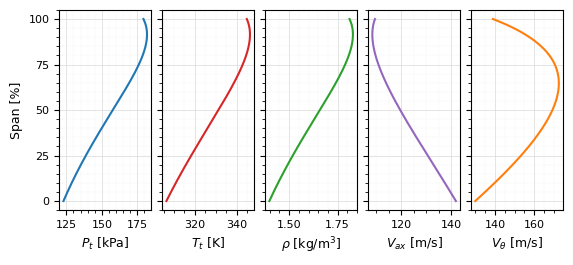

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction
exit_state = states[-1]
span = np.linspace(0, 100, exit_state.M) 

quantities = [
    (exit_state.P / 1e3,    r'$P_t$ [kPa]',      '#1f77b4'),
    (exit_state.T,          r'$T_t$ [K]',        '#d62728'),
    (exit_state.rho,         r'$\rho$ [kg/m$^3$]', '#2ca02c'),
    (exit_state.vax,         r'$V_{ax}$ [m/s]',   '#9467bd'),
    (exit_state.vtheta,      r'$V_{\theta}$ [m/s]', '#ff7f0e'),
]

# Using a slightly narrower aspect ratio to make them look more integrated
fig, axes = plt.subplots(1, 5, figsize=(6.5, 2.6), sharey=True)

for i, (q, label, color) in enumerate(quantities):
    ax = axes[i]
    ax.plot(q, span, color=color, linewidth=1.5)
    
    # AIAA Styling
    ax.set_xlabel(label, fontsize=9, labelpad=4)
    ax.tick_params(axis='both', labelsize=8)
    
    # Tight Grid
    ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5, color='0.85')
    ax.minorticks_on()
    ax.grid(visible=True, which='minor', linestyle=':', linewidth=0.3, color='0.9')
    
    if i == 0:
        ax.set_ylabel('Span [%]', fontsize=9)
        ax.set_yticks([0, 25, 50, 75, 100])

# Reduce padding between subplots significantly
# wspace=0.1 to 0.15 is usually the "sweet spot" for shared Y-axis plots
plt.subplots_adjust(wspace=0.12)

# Save high-res for the paper
plt.savefig('figures/rotor37_radial_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

## Monte Carlo Uncertainty Quantification

Latin Hypercube Sampling (LHS) is used to draw $N=10000$ samples across the
6-dimensional input space. Failed solver runs are retained as $\texttt{NaN}$ to
characterize the stability boundary of the solver.

In [39]:
import pandas as pd
from scipy.stats import qmc, norm

N_samples = 10000

sampler = qmc.LatinHypercube(d=6, seed=67)
sample = sampler.random(N_samples)

# Uniform variables
beta_hub_samples = qmc.scale(sample[:, [0]], 10, 20).ravel()
beta_tip_samples = qmc.scale(sample[:, [1]], 55, 65).ravel()
sigma_samples    = qmc.scale(sample[:, [2]], 0.88, 0.98).ravel()

# Normal variables via inverse CDF
eta_samples = norm.ppf(sample[:, 3], loc=0.900,  scale=0.015)
P0_samples  = norm.ppf(sample[:, 4], loc=P0,     scale=3000)
T0_samples  = norm.ppf(sample[:, 5], loc=T0,     scale=15)

## Monte Carlo Run

The solver is executed across all the LHS samples. Failed runs are retained
as $\texttt{NaN}$ and the convergence rate is reported.

In [40]:
from tqdm import tqdm
import os

RESULTS_PATH = '../data/rotor67_mc_results.csv'

if os.path.exists(RESULTS_PATH):
    df = pd.read_csv(RESULTS_PATH)
    print(f"Loaded existing results from {RESULTS_PATH}")
    print(f"Converged: {df['PR'].notna().sum()} / {len(df)} ({df['PR'].notna().mean()*100:.1f}%)")
else:
    results = []

    for i in tqdm(range(N_samples), desc="Monte Carlo"):
        try:
            rho0_i = P0_samples[i] / (R * T0_samples[i])
            
            beta_i = np.linspace(beta_hub_samples[i], beta_tip_samples[i], M)
            
            inlet_i = State(n=0, M=M, rm=rm, rp=rp,
                            T=T0_samples[i], P=P0_samples[i],
                            vax=vax_0, rho=rho0_i, vtheta=0)
            
            solver_i = MultistageFanSolver(
                N=1, M=M, direction=[1],
                sigma=sigma_samples[i], omega=omega,
                beta=beta_i, rp=rp, rm=rm,
                eta=eta_samples[i], R=R, cp=cp, gamma=gamma
            )
            
            states_i = solver_i.solve(inlet_state=inlet_i, verbose=False)
            perf = solver_i.performance()
            
            results.append({
                "beta_hub": beta_hub_samples[i],
                "beta_tip": beta_tip_samples[i],
                "sigma":    sigma_samples[i],
                "eta":      eta_samples[i],
                "P0":       P0_samples[i],
                "T0":       T0_samples[i],
                "PR":       perf["PR"],
                "TR":       perf["TR"],
                "eta_isen": perf["eta_isen"],
            })
        except Exception:
            results.append({
                "beta_hub": beta_hub_samples[i],
                "beta_tip": beta_tip_samples[i],
                "sigma":    sigma_samples[i],
                "eta":      eta_samples[i],
                "P0":       P0_samples[i],
                "T0":       T0_samples[i],
                "PR":       np.nan,
                "TR":       np.nan,
                "eta_isen": np.nan,
            })

    df = pd.DataFrame(results)
    df.to_csv(RESULTS_PATH, index=False)

print(f"Converged: {df['PR'].notna().sum()} / {N_samples} ({df['PR'].notna().mean()*100:.1f}%)")
df_clean = df.dropna(subset=['PR'])

Loaded existing results from ../data/rotor67_mc_results.csv
Converged: 10000 / 10000 (100.0%)
Converged: 10000 / 10000 (100.0%)


## Pressure Ratio Distribution

The histogram below shows the distribution of solver-predicted pressure ratio 
$\pi$ across all $N = 10{,}000$ LHS samples. The shaded band denotes the 90% 
confidence interval; the dashed line indicates the Rotor 67 experimental design 
value of $\pi = 1.63$. The mean predicted pressure ratio and its deviation from 
the experimental value are reported as the primary validation metric for the UQ 
case.

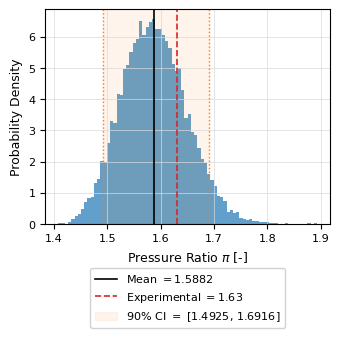

In [41]:
fig, ax = plt.subplots(figsize=(3.5, 3.6))

PR_clean = df_clean['PR']
PR_mean  = PR_clean.mean()
PR_p5    = PR_clean.quantile(0.05)
PR_p95   = PR_clean.quantile(0.95)

ax.hist(PR_clean, bins=80, density=True, color='#1f77b4', alpha=0.7, edgecolor='none')
ax.axvline(PR_mean, color='black',   linewidth=1.2, linestyle='-',
           label=f'Mean $= {PR_mean:.4f}$')
ax.axvline(1.63,    color='#d62728', linewidth=1.2, linestyle='--',
           label='Experimental $= 1.63$')
ax.axvspan(PR_p5, PR_p95, alpha=0.08, color='#ff7f0e',
           label=f'90% CI $=$ [{PR_p5:.4f}, {PR_p95:.4f}]')
ax.axvline(PR_p5,  color='#ff7f0e', linewidth=1.0, linestyle=':')
ax.axvline(PR_p95, color='#ff7f0e', linewidth=1.0, linestyle=':')

ax.set_xlabel('Pressure Ratio $\\pi$ [-]', fontsize=9)
ax.set_ylabel('Probability Density', fontsize=9)
ax.tick_params(labelsize=8)
ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5, color='0.85')
ax.legend(fontsize=8, framealpha=0.9, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), ncol=1)

fig.tight_layout()
plt.savefig('figures/rotor67_pr_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Sensitivity Analysis: Partial Rank Correlation Coefficients (PRCC)

PRCC measures the monotonic influence of each uncertain input on the output pressure
ratio $\pi$, after removing the effect of all other inputs. A PRCC value near $\pm 1$
indicates strong sensitivity; near $0$ indicates negligible influence. Spearman Rank
Correlation Coefficients (SRCC) are also computed as a non-partial reference.

In [42]:
from scipy.stats import spearmanr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



inputs = ['beta_hub', 'beta_tip', 'sigma', 'eta', 'P0', 'T0']
output = 'PR'

labels = {
    'beta_hub': r'$\beta_{hub}$',
    'beta_tip': r'$\beta_{tip}$',
    'sigma':    r'$\sigma$',
    'eta':      r'$\eta$',
    'P0':       r'$P_0$',
    'T0':       r'$T_0$',
}

def prcc(df, inputs, output):
    data = df[inputs + [output]].copy()
    ranked = data.rank()
    prcc_vals = {}
    for xi in inputs:
        others = [col for col in inputs if col != xi]
        X_others = ranked[others].values
        X_others = np.column_stack([np.ones(len(X_others)), X_others])
        xi_vals = ranked[xi].values
        y_vals  = ranked[output].values
        def ols_resid(X, y):
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            return y - X @ beta
        resid_xi = ols_resid(X_others, xi_vals)
        resid_y  = ols_resid(X_others, y_vals)
        prcc_vals[xi] = np.corrcoef(resid_xi, resid_y)[0, 1]
    return prcc_vals

# Spearman (non-partial)
spearman_vals = {xi: spearmanr(df_clean[xi], df_clean[output])[0] for xi in inputs}
spearman_sorted = dict(sorted(spearman_vals.items(), key=lambda x: abs(x[1])))

# PRCC (partial)
prcc_vals = prcc(df_clean, inputs, output)
prcc_sorted = dict(sorted(prcc_vals.items(), key=lambda x: abs(x[1])))

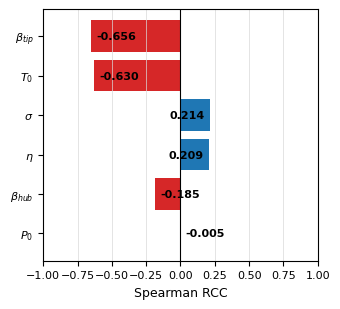

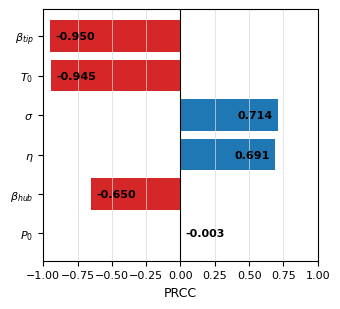

In [43]:
def plot_tornado(vals_sorted, xlabel, savepath):
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in vals_sorted.values()]
    bars = ax.barh([labels[k] for k in vals_sorted], list(vals_sorted.values()), color=colors)
    for bar, (k, v) in zip(bars, vals_sorted.items()):
        x_pos = v - 0.04 if v > 0 else v + 0.04
        ha = 'right' if v > 0 else 'left'
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', ha=ha,
                fontsize=8, fontweight='bold', color='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5, color='0.85', axis='x')
    ax.set_xlim([-1, 1])
    fig.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

plot_tornado(spearman_sorted, 'Spearman RCC', 'figures/rotor67_srcc.png')
plot_tornado(prcc_sorted,     'PRCC',          'figures/rotor67_prcc.png')